Behaivoural Analysis on general dataset based on results from logistic regression w2v model 

In [1]:
import pandas as pd
#initialisation cell - imports and loading up labelled depression dataset
import pandas as pd
import contractions
import re
import emoji
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import nltk
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
import matplotlib.pyplot as plt
import numpy as np
from sklearn.utils import resample
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import gensim
from gensim.models import Word2Vec
from sklearn.decomposition import LatentDirichletAllocation
import pyLDAvis
#import pyLDAvis.sklearn
import pyLDAvis.lda_model
import pickle 
import seaborn as sns 

tweets = pd.read_csv('general_with_predictions.csv')
#tfidf_tweets = pd.read_csv('General_Dataset_TF-IDF_vectorised_tweets.csv')

In [2]:
tweets.head

<bound method NDFrame.head of         _unit_id  gender  gender:confidence           created  \
0      815719226    male             1.0000  12/05/2013 01:48   
1      815719227    male             1.0000  10/01/2012 13:51   
2      815719228    male             0.6625    11/28/14 11:30   
3      815719229    male             1.0000  06/11/2009 22:39   
4      815719230  female             1.0000     4/16/14 13:23   
...          ...     ...                ...               ...   
11891  815757572  female             1.0000  08/05/2015 21:16   
11892  815757681    male             1.0000     8/15/12 21:17   
11893  815757830    male             1.0000  09/03/2012 01:17   
11894  815757921  female             0.8489  11/06/2012 23:46   
11895  815757985  female             1.0000     4/14/14 17:22   

                                             description  fav_number  \
0                                  i sing my own rhythm.           0   
1      I'm the author of novels filled with f

In [128]:
tweets['tweet_count'].head()

0    110964
1      7471
2      5617
3      1693
4     31462
Name: tweet_count, dtype: int64

In [4]:
depressed_count = tweets['predicted_label_w2vlogreg'].value_counts()
print(depressed_count)

predicted_label_w2vlogreg
0    11213
1      683
Name: count, dtype: int64


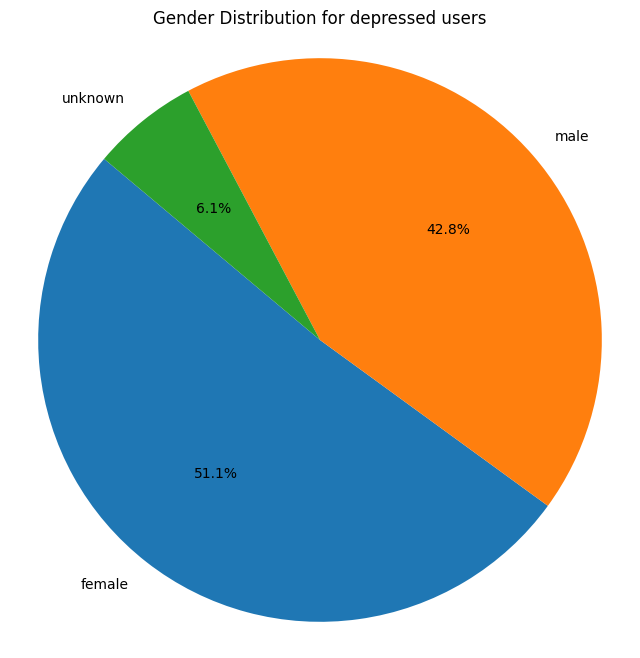

In [6]:
##gender distribution for depressed users 
##gender split in the dataset 
depressed = tweets[tweets['predicted_label_w2vlogreg']==1]
non_depressed = tweets[tweets['predicted_label_w2vlogreg']==0]

gender_depressed = depressed['gender'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(gender_depressed,labels=gender_depressed.index,autopct='%1.1f%%', startangle=140)
plt.axis('equal') 
plt.title('Gender Distribution for depressed users')
plt.show()

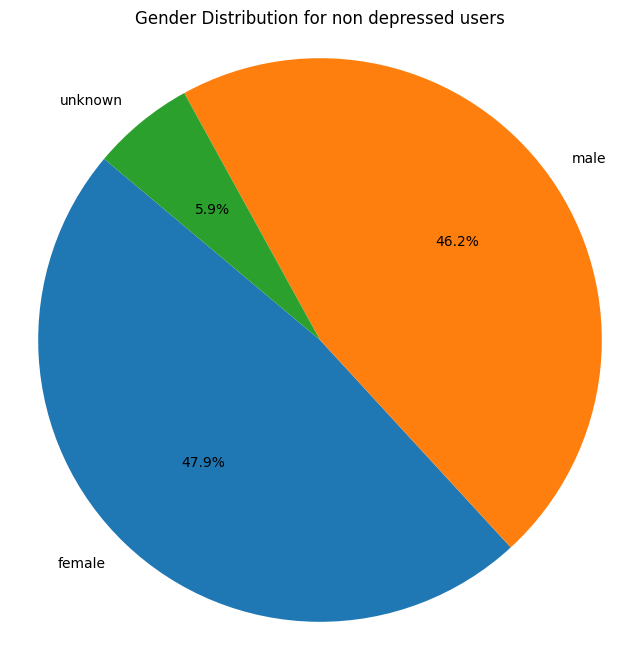

In [7]:
#non_depressed = tweets[tweets['predicted_label_svm']==0]

gender_non_depressed = non_depressed['gender'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(gender_non_depressed,labels=gender_non_depressed.index,autopct='%1.1f%%', startangle=140)
plt.axis('equal') 
plt.title('Gender Distribution for non depressed users')
plt.show()

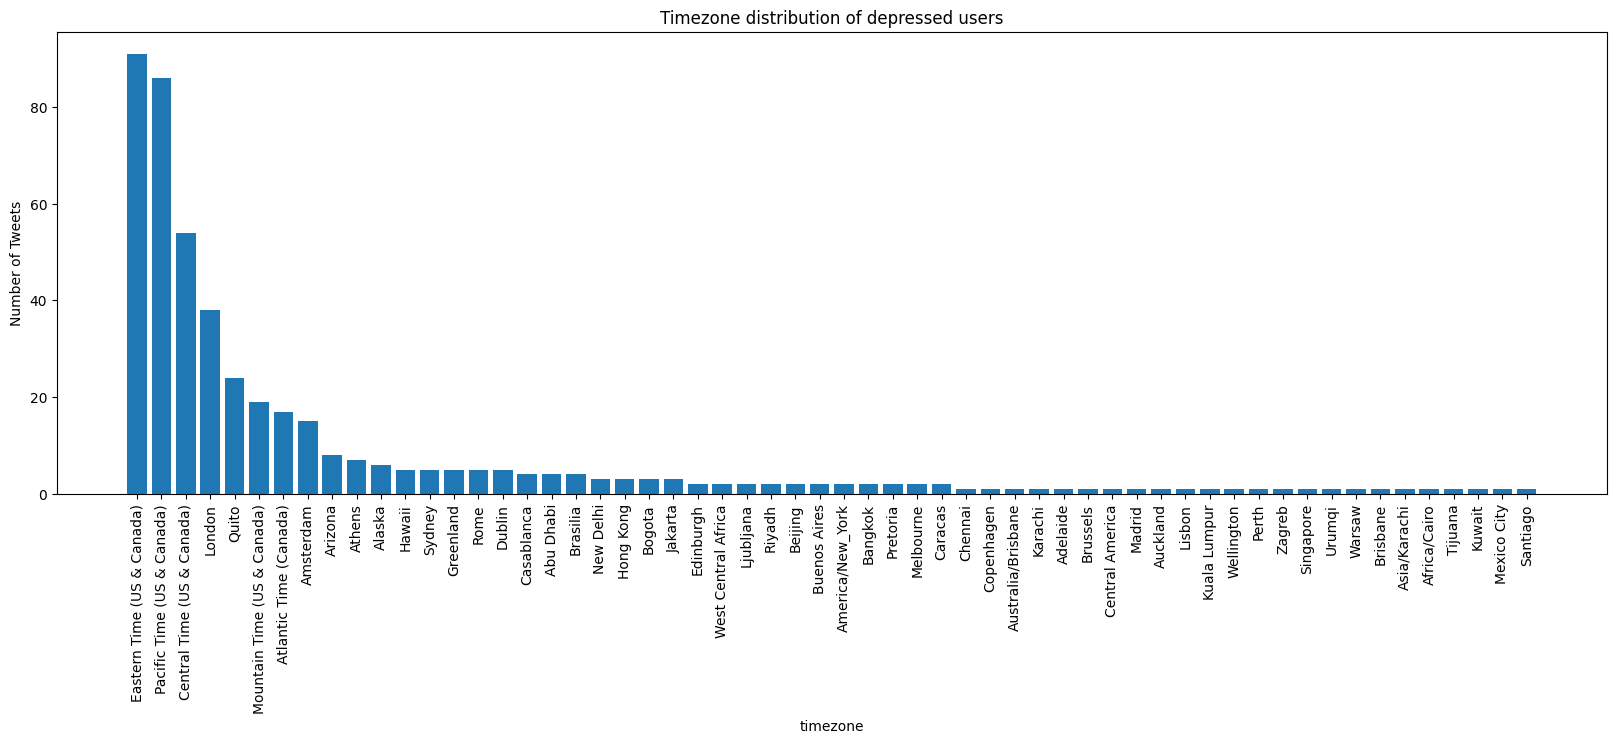

In [8]:
##location split in the dataset for depressed users
timezone = depressed['user_timezone'].value_counts()

#Creating bar chart 
plt.figure(figsize=(20, 6))
plt.bar(timezone.index, timezone.values)

plt.xlabel('timezone')
plt.ylabel('Number of Tweets')
plt.title('Timezone distribution of depressed users')
plt.xticks(rotation=90)

plt.show()
##same location trends showing between whole dataset and location of depressed users 

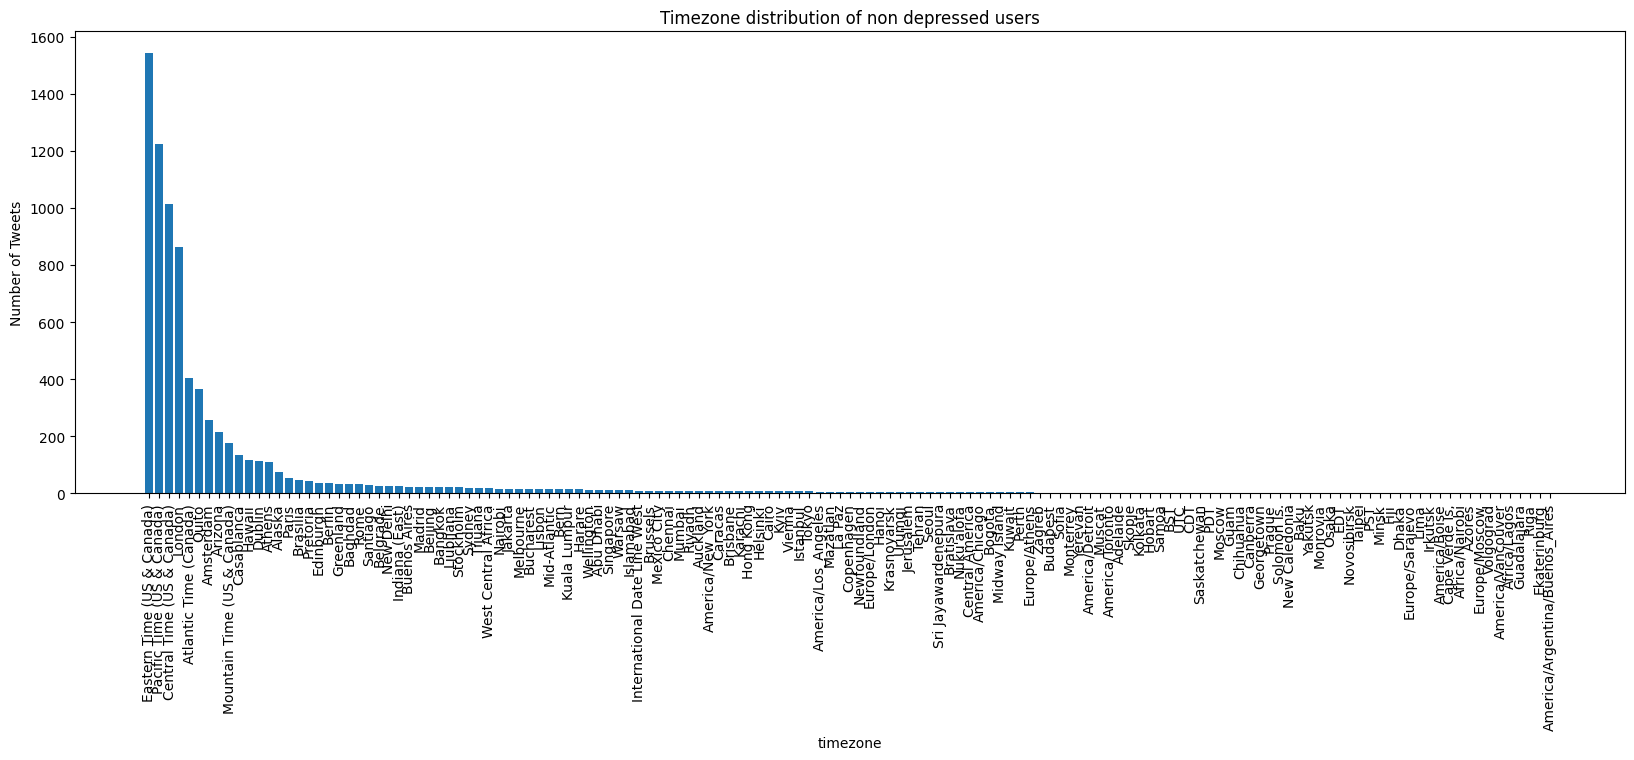

In [9]:
##location split in the dataset for depressed users
timezone = non_depressed['user_timezone'].value_counts()
plt.figure(figsize=(20, 6))
plt.bar(timezone.index, timezone.values)


plt.xlabel('timezone')
plt.ylabel('Number of Tweets')
plt.title('Timezone distribution of non depressed users')
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability if there are many users


plt.show()

In [10]:
not_null_hashtags_depressed=depressed[depressed['hashtags'].apply(lambda x: bool(x))]
print(depressed)

        _unit_id   gender  gender:confidence           created  \
47     815719294   female             1.0000  09/11/2015 14:30   
61     815719313   female             1.0000  11/03/2012 15:50   
63     815719320     male             1.0000  08/05/2010 08:31   
77     815719340   female             1.0000  02/02/2012 11:55   
85     815719353     male             1.0000    10/28/12 14:29   
...          ...      ...                ...               ...   
11806  815739516   female             1.0000  06/10/2013 16:04   
11823  815739541  unknown             0.3446  05/04/2011 20:52   
11831  815739551   female             1.0000      5/31/12 9:05   
11864  815746503     male             0.9612  08/05/2010 08:31   
11885  815756011   female             0.9622  08/02/2014 10:19   

                                             description  fav_number  \
47                           walk by faith not by sight.         109   
61                                     Charity volunteer      1

<Axes: ylabel='Frequency'>

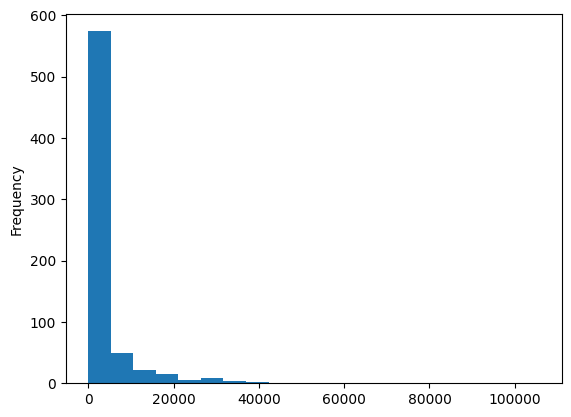

In [11]:
depressed['fav_number'].plot.hist(bins=20)

<Axes: ylabel='Frequency'>

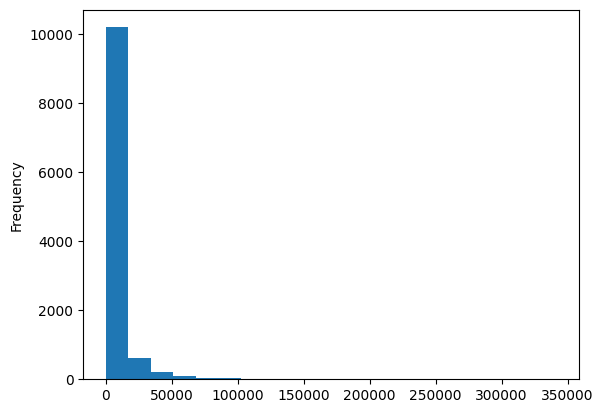

In [12]:
non_depressed['fav_number'].plot.hist(bins=20)

C:\Users\mayur\AppData\Local\Temp\ipykernel_46904\579133260.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  depressed['created'] = pd.to_datetime(depressed['created'],format='mixed')
C:\Users\mayur\AppData\Local\Temp\ipykernel_46904\579133260.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  depressed['profile_time'] = depressed['created'].dt.hour


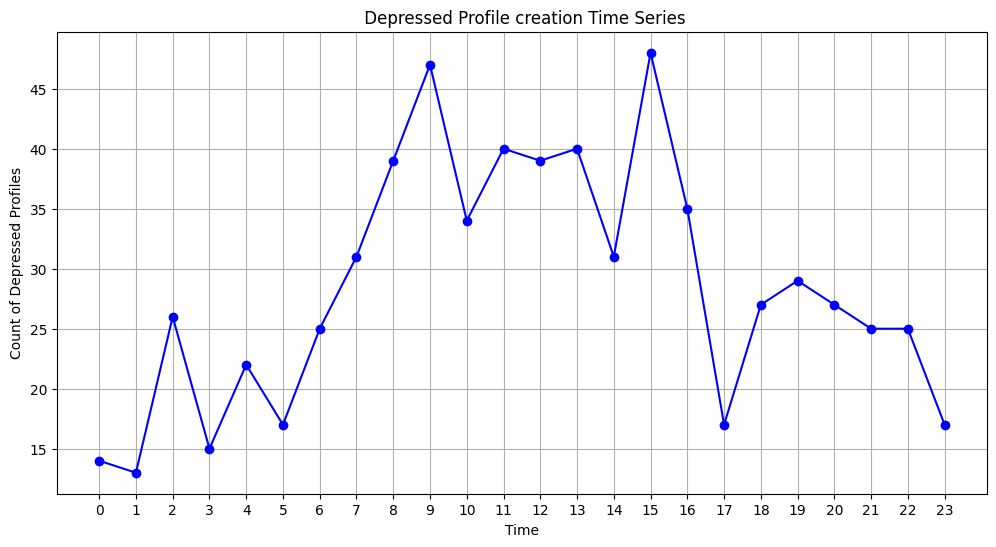

In [13]:
##depressed tweets and time tweet created 
depressed['created'] = pd.to_datetime(depressed['created'],format='mixed')

depressed['profile_time'] = depressed['created'].dt.hour
# Create a new DataFrame with the count of depressed tweets per day
depressed_tweets_count = depressed.groupby('profile_time').size().reset_index(name='count')


#depressed_tweets_count.set_index('tweet_created', inplace=True)


plt.figure(figsize=(12, 6))
plt.plot(depressed_tweets_count['profile_time'], depressed_tweets_count['count'], marker='o', linestyle='-', color='b')
plt.xlabel('Time')
plt.ylabel('Count of Depressed Profiles')
plt.title(' Depressed Profile creation Time Series')
plt.xticks(range(24))  # Ensure x-axis shows all hours (0-23)
plt.grid(True)
plt.show()

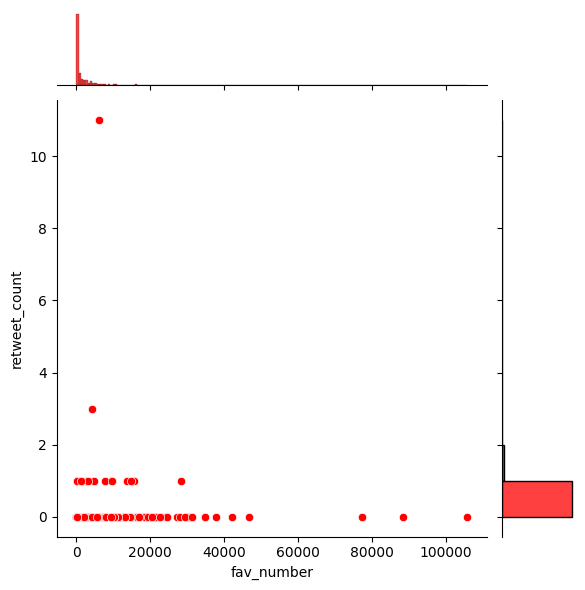

In [14]:
sns.jointplot(x='fav_number',y='retweet_count',data=depressed,kind='scatter',color='red')

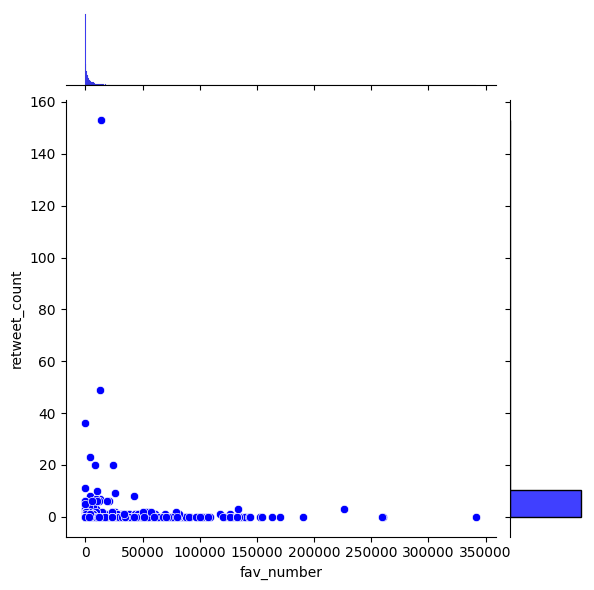

In [15]:
sns.jointplot(x='fav_number',y='retweet_count',data=non_depressed,kind='scatter',color='blue')

<Axes: xlabel='gender', ylabel='count'>

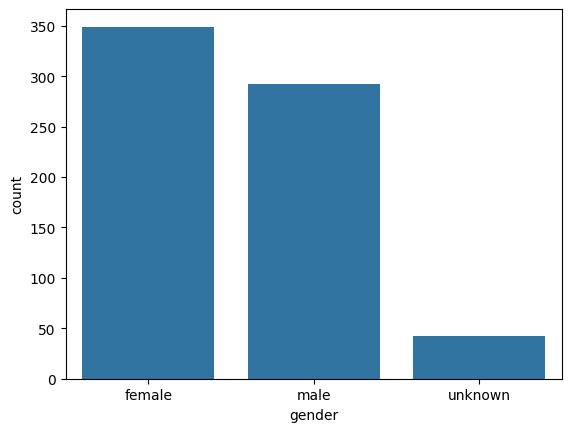

In [16]:
sns.countplot(x='gender', data=depressed)

<Axes: xlabel='gender', ylabel='fav_number'>

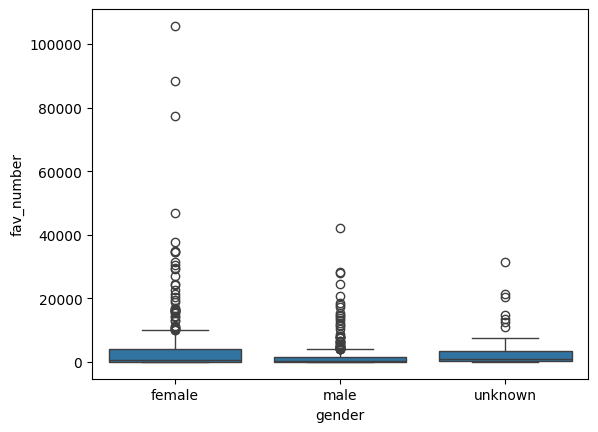

In [17]:
sns.boxplot(x='gender',y='fav_number', data=depressed)

<Axes: xlabel='created', ylabel='fav_number'>

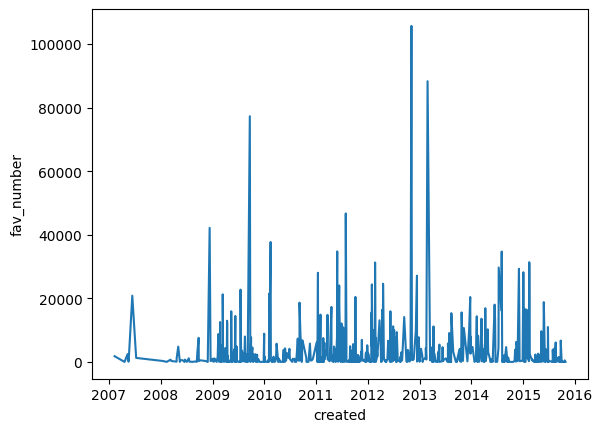

In [18]:
sns.lineplot(x='created', y='fav_number', data=depressed)

<Axes: xlabel='gender', ylabel='fav_number'>

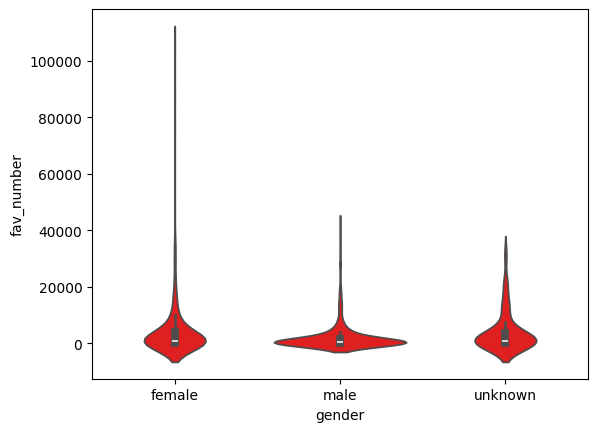

In [20]:
sns.violinplot(x="gender", y="fav_number", data=depressed, color='r')

<Axes: xlabel='gender', ylabel='fav_number'>

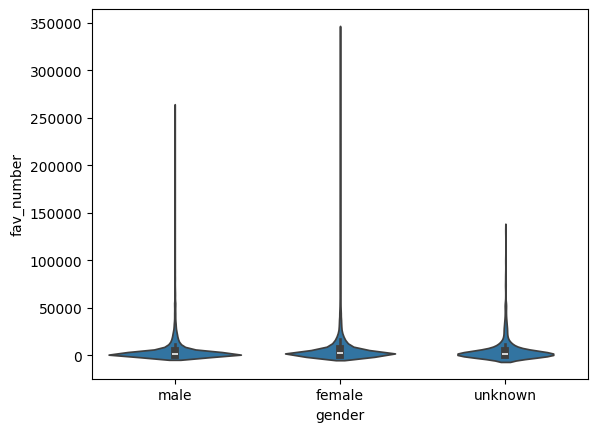

In [21]:
sns.violinplot(x="gender", y="fav_number", data=non_depressed)

<Axes: xlabel='gender', ylabel='tweet_count'>

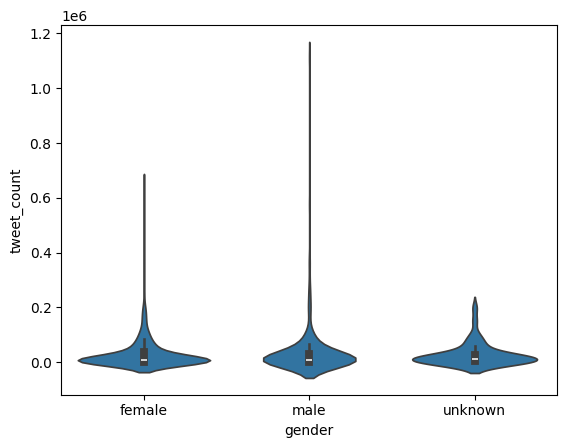

In [22]:
sns.violinplot(x="gender", y="tweet_count", data=depressed)

<Axes: xlabel='gender', ylabel='tweet_count'>

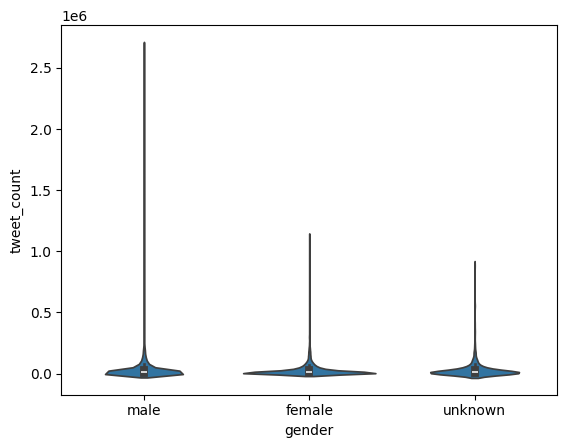

In [23]:
sns.violinplot(x="gender", y="tweet_count", data=non_depressed)

In [24]:
depressed.head

<bound method NDFrame.head of         _unit_id   gender  gender:confidence             created  \
47     815719294   female             1.0000 2015-09-11 14:30:00   
61     815719313   female             1.0000 2012-11-03 15:50:00   
63     815719320     male             1.0000 2010-08-05 08:31:00   
77     815719340   female             1.0000 2012-02-02 11:55:00   
85     815719353     male             1.0000 2012-10-28 14:29:00   
...          ...      ...                ...                 ...   
11806  815739516   female             1.0000 2013-06-10 16:04:00   
11823  815739541  unknown             0.3446 2011-05-04 20:52:00   
11831  815739551   female             1.0000 2012-05-31 09:05:00   
11864  815746503     male             0.9612 2010-08-05 08:31:00   
11885  815756011   female             0.9622 2014-08-02 10:19:00   

                                             description  fav_number  \
47                           walk by faith not by sight.         109   
61       

Hashtag analyses 

In [25]:
##top 20 used hashtags for depressed and non depressed uers 

depressed_hashtags = depressed['hashtags']
non_depressed_hashtags= non_depressed['hashtags']

# makes sure all hashtages  are strings and concatenate them
depressed_hashtags = ','.join(depressed_hashtags.dropna().apply(lambda x: ', '.join(x) if isinstance(x, list) else x))
non_depressed_hashtags = ','.join(non_depressed_hashtags.dropna().apply(lambda x: ', '.join(x) if isinstance(x, list) else x))


def tokenize_and_count(hashtags_str):
    return [tag.strip() for tag in hashtags_str.split(',')]

depressed_hashtag_counts = Counter(tokenize_and_count(depressed_hashtags))
non_depressed_hashtag_counts = Counter(tokenize_and_count(non_depressed_hashtags))

# Top hashtags
top_depressed_hashtags = depressed_hashtag_counts.most_common(100)
top_non_depressed_hashtags = non_depressed_hashtag_counts.most_common(100)

print('Top 20 depressed hashtags: ', top_depressed_hashtags)
print()
print('Top 20 non depressed hashtags: ', top_non_depressed_hashtags)

Top 20 depressed hashtags:  [('[]', 512), ("['FALive']", 4), ("['Repost'", 3), ("['OTWOLHappyTimes'", 3), ("'PushAwardsJaDines']", 3), ("['webdesign']", 2), ("['LeesQANDA']", 2), ("['health'", 2), ("['business'", 2), ("['Post'", 2), ("'new'", 2), ("'retweet']", 2), ("'tampons']", 2), ("['forex']", 2), ("['health']", 2), ("['BrockLesnar']", 2), ("['IranDeal'", 2), ("'UNSC'", 2), ("'Iran']", 2), ("['empoweringyou']", 2), ("['money'", 1), ("'IRS']", 1), ("['sailing'", 1), ("'IAN']", 1), ("['publishing'", 1), ("'authors']", 1), ("['BigTits'", 1), ("'Boobs'", 1), ("'Tits']", 1), ("['ConcentrationProblems']", 1), ("'dab'", 1), ("'kdbrand'", 1), ("'wolfpackjacket']", 1), ("['ElixirShow']", 1), ("['SPECTREpremiere']", 1), ("['exercise']", 1), ("['infinitycat'", 1), ("'JEFFTheBrotherhood'", 1), ("'vinyl']", 1), ("['Pilot'", 1), ("'TVSeries'", 1), ("'writing']", 1), ("['iphone'", 1), ("'apple']", 1), ("['FreeMorgan'", 1), ("'Blackfish']", 1), ("['headshot'", 1), ("'actorslife'", 1), ("'nycactor'

LDA - topic modelling 
* Topic modelling on the depressed/ non depressed description 
* Topic modelling on the depressed/ non depressed tweets

In [31]:
depressed['lemmatised'].head()

47                 ['hidden', 'umph', 'co', 'onebbsag']
61    ['move', 'week', 'double', 'leg', 'stretch', '...
63    ['reimagining', 'webdesign', 'process', 'invis...
77         ['lrt', 'work', 'allllllllllllllll', 'time']
85    ['stats', 'day', 'arrive', 'new', 'unfollower'...
Name: lemmatised, dtype: object

In [59]:
import gensim
from gensim.models import LdaModel
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary
import ast
#depressed['lemmatised'].head()
##MEANINGFUL TOPICS FOUND
documents = depressed['lemmatised'].apply(lambda x: ast.literal_eval(x))

#Gensim dictionary from cleaned/tokenised profiles - the words presents in the prfiles
dictionary = Dictionary(documents)
# Gensim corpus from the tokenized profiles in 'non depressed' 
corpus = [dictionary.doc2bow(doc) for doc in documents]
#lda = LdaModel(corpus, num_topics=10,passes= 15, id2word=dictionary, decay=0.5, iterations=50)
lda = LdaModel(corpus, num_topics=15,passes= 15, id2word=dictionary, decay=0.3, iterations=50)


def show_topics(lda, feature_names, top_word_num):
    count=1
    for topic_idx, topic in enumerate(lda.components_):
        print("Topic" ,topic_idx)
        print (" ".join([feature_names[i]
                        for i in topic.argsort()[:-top_word_num - 1:-1]]))
        count+=1
topic_coherence_words = []
topics = lda.print_topics(num_words=50) 

for topic_id in range(lda.num_topics):
    top_words = [word for word, _ in lda.show_topic(topic_id, topn=50)]
    print(f"Topic {topic_id + 1}: {', '.join(top_words)}")
    print()

coherence_model = CoherenceModel(model=lda, texts=documents, dictionary=dictionary, coherence='c_v')
coherence_score = coherence_model.get_coherence()
print(f'Coherence Score: {coherence_score}')

Topic 1: co, blog, way, best, pushawardsjadines, otwolhappytimes, goodvibes, deal, post, night, etc, bidness, hockey, global, govt, twilight, forex, world, via, cure, bit, health, doctor, back, death, future, iran, stonewall, unsc, pave, nuclear, khamenei, irandeal, violation, compel, approve, feature, blogging, week, international, site, magnessmayhem, perspective, great, blue, indie, poke, see, without, fund

Topic 2: co, take, time, back, bit, via, much, big, help, mumshour, love, textile, mental, health, test, attempt, news, work, friday, th, happy, v, blog, wqbeigwd, birthday, old, joxcyjkwt, meet, xiao, needytimes, since, hwanhee, murderous, corruption, uption, cute, dweeb, fight, feat, indiatwo, happywooshinday, santhanam, year, artist, apparently, rawart, artbrut, art, chat, wabisabistar

Topic 3: co, via, child, bit, time, mother, work, gt, amp, get, today, take, video, idea, host, challenge, halloween, check, ebb, right, site, column, babe, repost, back, youtube, life, go, ca

In [60]:
documents = non_depressed['lemmatised'].apply(lambda x: ast.literal_eval(x))

#Gensim dictionary from cleaned/tokenised profiles - the words presents in the prfiles
dictionary = Dictionary(documents)
# Gensim corpus from the tokenized profiles in 'non depressed' 
corpus = [dictionary.doc2bow(doc) for doc in documents]
lda = LdaModel(corpus, num_topics=20,passes= 15, id2word=dictionary, decay=0.3, iterations=50)


def show_topics(lda, feature_names, top_word_num):
    count=1
    for topic_idx, topic in enumerate(lda.components_):
        print("Topic" ,topic_idx)
        print (" ".join([feature_names[i]
                        for i in topic.argsort()[:-top_word_num - 1:-1]]))
        count+=1
topic_coherence_words = []
topics = lda.print_topics(num_words=50) 

for topic_id in range(lda.num_topics):
    top_words = [word for word, _ in lda.show_topic(topic_id, topn=50)]
    print(f"Topic {topic_id + 1}: {', '.join(top_words)}")
    print()

coherence_model = CoherenceModel(model=lda, texts=documents, dictionary=dictionary, coherence='c_v')
coherence_score = coherence_model.get_coherence()
print(f'Coherence Score: {coherence_score}')

Topic 1: want, co, people, like, start, really, feel, check, get, live, one, right, real, also, black, good, know, do, care, kind, follow, anyone, damn, thing, see, moment, work, think, ever, reason, need, life, v, always, question, amp, charge, show, blue, happen, make, might, personal, struggle, hell, without, hey, age, list, look
Topic 2: year, co, favorite, onedirection, buy, amas, go, long, old, dress, honest, along, artist, ok, thought, small, trust, chicken, hop, rich, rock, pop, group, study, plus, water, expect, outfit, memory, louis, scream, carson, compare, ago, deal, design, argue, summer, leg, quick, stream, tf, congrats, partner, bottle, poll, member, away, stuff, charity
Topic 3: meet, co, twitter, stay, send, sometimes, party, maybe, pay, support, away, wonder, door, account, sweet, practice, coffee, parent, hotel, earth, tour, swear, shirt, million, ring, jack, bill, piss, john, text, match, drake, return, copy, instagram, switch, lesson, show, middle, cost, lunch, bit

Profile topic modelling for depressed and non depressed users 

In [41]:
###Tweet column cleaning ###
#for the post_text column specifically as it is longer text more cleaning + preprocessing required

from langdetect import detect
##removing numbers 
def remove_numbers(tweet):
    return ''.join([char for char in tweet if not char.isdigit()])
depressed['desc_clean'] = depressed['description'].apply(remove_numbers)

### fixing contractions  
def fix_contractions(tweet):
    return contractions.fix(tweet)
depressed['desc_clean'] = depressed['desc_clean'].apply(fix_contractions)
print(depressed['desc_clean'].head)

### removing punctuation and special characters 
depressed['desc_clean'] = depressed['desc_clean'].str.replace('\W',' ',regex=True)


#print(depressed['desc_clean'].head)
def remove_words_with_number(text):
    return re.sub(r'\b\w*\d\w*\b', '',text)
depressed['desc_clean'] = depressed['desc_clean'].apply(remove_words_with_number)
### remove non-alphanumeric characters and extra spaces
def remove_non_alphanumeric(text):
    return re.sub(r'[^a-zA-Z0-9\s]', '', text)
depressed['desc_clean'] = depressed['desc_clean'].apply(remove_non_alphanumeric)

def remove_links(text):
    return re.sub(r'(@[A-Za-z0–9_]+)|[^\w\s]|#|http\S+', '',text)
depressed['desc_clean'] = depressed['desc_clean'].apply(remove_links)
### removing URLs from tweets
#tweets['post_text'] = tweets['post_text'].str.replace('http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', ' ')
depressed['desc_clean'] = depressed['desc_clean'].apply(lambda text: re.sub(r'https?:\/\/\S*', '', text, flags=re.MULTILINE))

### convert text to lower case
depressed['desc_clean'] = depressed['desc_clean'].str.lower()

### removing emojis 
def remove_emojis(text):
    #text repesention of emojis 
    emojis_text_rep = emoji.demojize(text)
    clean_text = re.sub(r':[a-zA-Z_]+:', '', emojis_text_rep)
    return clean_text

depressed['desc_clean'] = depressed['desc_clean'].apply(remove_emojis)

def remove_non_english_words(text):
    try:
        return detect(text)=='en'
    except:
        return False 
depressed['desc_clean']= depressed['desc_clean'].apply(lambda x: '' if not remove_non_english_words(x) else x)
    

print(depressed['desc_clean'].head)

<>:15: DeprecationWarning: invalid escape sequence '\w'
<>:23: DeprecationWarning: invalid escape sequence '\W'
<>:15: DeprecationWarning: invalid escape sequence '\w'
<>:23: DeprecationWarning: invalid escape sequence '\W'
C:\Users\mayur\AppData\Local\Temp\ipykernel_46904\363087660.py:15: DeprecationWarning: invalid escape sequence '\w'
  '''
C:\Users\mayur\AppData\Local\Temp\ipykernel_46904\363087660.py:23: DeprecationWarning: invalid escape sequence '\W'
  depressed['desc_clean'] = depressed['desc_clean'].str.replace('\W',' ',regex=True)
C:\Users\mayur\AppData\Local\Temp\ipykernel_46904\363087660.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  depressed['desc_clean'] = depressed['description'].apply(remove_numbers)
C:\Users\mayur\AppData\L

<bound method NDFrame.head of 47                             walk by faith not by sight.
61                                       Charity volunteer
63       Maker, Conceptor & Creative Developer - xBACAB...
77                                          Leonel Dominic
85                                           hollow heart.
                               ...                        
11806    the dreamy Grimes protÌ©gÌ© / \nbitch has @MsS...
11823    Lover of expression, cultures and quirks. Inte...
11831    Executive Strategist empowering communities to...
11864    Maker, Conceptor & Creative Developer - xBACAB...
11885     // snapchat: sianfreya.xÏ¬ @caitlin_zz_ü...
Name: desc_clean, Length: 683, dtype: object>
<bound method NDFrame.head of 47                             walk by faith not by sight 
61                                                        
63       maker  conceptor   creative developer   xbacab...
77                                                        
85       

C:\Users\mayur\AppData\Local\Temp\ipykernel_46904\363087660.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  depressed['desc_clean']= depressed['desc_clean'].apply(lambda x: '' if not remove_non_english_words(x) else x)


In [42]:
##tokensie and removing stop words
depressed['desc_clean'] = depressed['desc_clean'].apply(lambda text: word_tokenize(text))
stop_words = set(stopwords.words('english'))
depressed['desc_clean'] = depressed['desc_clean'].apply(lambda x: [word for word in x if word not in stop_words])
print(depressed['desc_clean'])


47                                    [walk, faith, sight]
61                                                      []
63       [maker, conceptor, creative, developer, xbacab...
77                                                      []
85                                         [hollow, heart]
                               ...                        
11806    [dreamy, grimes, prot, g, bitch, mssarahpaulso...
11823    [lover, expression, cultures, quirks, interest...
11831    [executive, strategist, empowering, communitie...
11864    [maker, conceptor, creative, developer, xbacab...
11885    [snapchat, sianfreya, x, caitlinzz, jacks, new...
Name: desc_clean, Length: 683, dtype: object


C:\Users\mayur\AppData\Local\Temp\ipykernel_46904\1992362201.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  depressed['desc_clean'] = depressed['desc_clean'].apply(lambda text: word_tokenize(text))
C:\Users\mayur\AppData\Local\Temp\ipykernel_46904\1992362201.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  depressed['desc_clean'] = depressed['desc_clean'].apply(lambda x: [word for word in x if word not in stop_words])


In [57]:
import gensim
from gensim.models import LdaModel
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary

documents = depressed['desc_clean'].tolist()

#Gensim dictionary from cleaned/tokenised profiles - the words presents in the prfiles
dictionary = Dictionary(documents)
# Gensim corpus from the tokenized profiles in 'depressed' 
corpus = [dictionary.doc2bow(doc) for doc in documents]

# Train LDA model on depressed prfile corpus

lda_model = LdaModel(corpus, num_topics=20, id2word=dictionary, passes=17,eta=0.1, random_state=42, iterations= 10, alpha =0.5) # most coherent topics with these hyperaparamters based on coherence score!

#lda_model = LdaModel(corpus, num_topics=20, id2word=dictionary, passes=17,eta=0.1, random_state=42, iterations= 10, alpha =0.3)

topic_coherence_words = []
topics = lda_model.print_topics(num_words=50) 

for topic_id in range(lda_model.num_topics):
    top_words = [word for word, _ in lda_model.show_topic(topic_id, topn=70)]
    print(f"Topic {topic_id + 1}: {', '.join(top_words)}")
    print()


# coherence score - how coherent is this lda model at distinguishing topics 
coherence_model = CoherenceModel(model=lda_model, texts=documents, dictionary=dictionary, coherence='c_v')
coherence_score = coherence_model.get_coherence()
print(f'Coherence Score: {coherence_score}')

Topic 1: enthusiast, one, university, sports, follower, rip, writer, follow, game, cats, hockey, luke, bitcoin, fine, got, editor, trying, co, com, life, reading, world, professional, partner, traveller, obsessed, student, baseball, cook, interested, k, us, figure, day, adventures, art, statistics, skiing, nba, dining, thrones, oh, give, trip, dare, oregonian, ba, spend, journalism, karma, awesome, faith, look, also, professor, else, artist, company, tweet, lil, technology, say, small, educator, like, ask, school, story, bit, mommy

Topic 2: travel, want, anti, really, animal, love, lover, life, student, com, music, kevrei, jersey, politics, call, new, gmail, girl, artist, fan, money, write, best, mission, western, mc, passionate, nintendo, expert, ii, luxenails, coast, theater, revelation, feed, simple, woman, blacklivesmatter, england, notebook, church, managing, sometimes, cold, home, sports, cool, running, story, queen, activist, independent, youtube, law, away, maker, id, film, ye

non depressed profile topic modelling 

In [46]:
##cleaning non depressed profile column
###Tweet column cleaning ###
#for the post_text column specifically as it is longer text more cleaning + preprocessing required

from langdetect import detect
##removing numbers 
def remove_numbers(tweet):
    return ''.join([char for char in tweet if not char.isdigit()])
non_depressed['desc_clean'] = non_depressed['description'].apply(remove_numbers)

### fixing contractions  
def fix_contractions(tweet):
    return contractions.fix(tweet)
non_depressed['desc_clean'] = non_depressed['desc_clean'].apply(fix_contractions)
print(non_depressed['desc_clean'].head)

### removing punctuation and special characters 
non_depressed['desc_clean'] = non_depressed['desc_clean'].str.replace('\W',' ',regex=True)


#print(depressed['desc_clean'].head)
def remove_words_with_number(text):
    return re.sub(r'\b\w*\d\w*\b', '',text)
non_depressed['desc_clean'] = non_depressed['desc_clean'].apply(remove_words_with_number)
### remove non-alphanumeric characters and extra spaces
def remove_non_alphanumeric(text):
    return re.sub(r'[^a-zA-Z0-9\s]', '', text)
non_depressed['desc_clean'] = non_depressed['desc_clean'].apply(remove_non_alphanumeric)

def remove_links(text):
    return re.sub(r'(@[A-Za-z0–9_]+)|[^\w\s]|#|http\S+', '',text)
non_depressed['desc_clean'] = non_depressed['desc_clean'].apply(remove_links)
### removing URLs from tweets
#tweets['post_text'] = tweets['post_text'].str.replace('http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', ' ')
non_depressed['desc_clean'] = non_depressed['desc_clean'].apply(lambda text: re.sub(r'https?:\/\/\S*', '', text, flags=re.MULTILINE))

### convert text to lower case
non_depressed['desc_clean'] = non_depressed['desc_clean'].str.lower()

### removing emojis 
def remove_emojis(text):
    #text repesention of emojis 
    emojis_text_rep = emoji.demojize(text)
    clean_text = re.sub(r':[a-zA-Z_]+:', '', emojis_text_rep)
    return clean_text

non_depressed['desc_clean'] = non_depressed['desc_clean'].apply(remove_emojis)

def remove_non_english_words(text):
    try:
        return detect(text)=='en'
    except:
        return False 
non_depressed['desc_clean']= non_depressed['desc_clean'].apply(lambda x: '' if not remove_non_english_words(x) else x)
    

print(non_depressed['desc_clean'].head)

<>:16: DeprecationWarning: invalid escape sequence '\w'
<>:24: DeprecationWarning: invalid escape sequence '\W'
<>:16: DeprecationWarning: invalid escape sequence '\w'
<>:24: DeprecationWarning: invalid escape sequence '\W'
C:\Users\mayur\AppData\Local\Temp\ipykernel_46904\2379766893.py:16: DeprecationWarning: invalid escape sequence '\w'
  '''
C:\Users\mayur\AppData\Local\Temp\ipykernel_46904\2379766893.py:24: DeprecationWarning: invalid escape sequence '\W'
  non_depressed['desc_clean'] = non_depressed['desc_clean'].str.replace('\W',' ',regex=True)
C:\Users\mayur\AppData\Local\Temp\ipykernel_46904\2379766893.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_depressed['desc_clean'] = non_depressed['description'].apply(remove_numbers)
C:\Us

<bound method NDFrame.head of 0                                    i sing my own rhythm.
1        I am the author of novels filled with family d...
2                      louis whining and squealing and all
3        Mobile guy.  ers, Shazam, Google, Kleiner Perk...
4        Ricky Wilson The Best FRONTMAN/Kaiser Chiefs T...
                               ...                        
11891                                                 (rp)
11892    Whatever you like, it is not a problem at all....
11893    #TeamBarcelona ..You look lost so you should f...
11894    Anti-statist; I homeschool my kids. Aspiring t...
11895                       Teamwork makes the dream work.
Name: desc_clean, Length: 11213, dtype: object>


C:\Users\mayur\AppData\Local\Temp\ipykernel_46904\2379766893.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_depressed['desc_clean'] = non_depressed['desc_clean'].str.lower()
C:\Users\mayur\AppData\Local\Temp\ipykernel_46904\2379766893.py:58: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_depressed['desc_clean'] = non_depressed['desc_clean'].apply(remove_emojis)


<bound method NDFrame.head of 0                                                         
1        i am the author of novels filled with family d...
2                      louis whining and squealing and all
3        mobile guy   ers  shazam  google  kleiner perk...
4        ricky wilson the best frontman kaiser chiefs t...
                               ...                        
11891                                                     
11892    whatever you like  it is not a problem at all ...
11893     teambarcelona   you look lost so you should f...
11894    anti statist  i homeschool my kids  aspiring t...
11895                       teamwork makes the dream work 
Name: desc_clean, Length: 11213, dtype: object>


C:\Users\mayur\AppData\Local\Temp\ipykernel_46904\2379766893.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_depressed['desc_clean']= non_depressed['desc_clean'].apply(lambda x: '' if not remove_non_english_words(x) else x)


In [47]:
##tokensie and removing stop words
non_depressed['desc_clean'] = non_depressed['desc_clean'].apply(lambda text: word_tokenize(text))
stop_words = set(stopwords.words('english'))
non_depressed['desc_clean'] = non_depressed['desc_clean'].apply(lambda x: [word for word in x if word not in stop_words])
print(non_depressed['desc_clean'])
##not removing stop words in this instance because it provide value to some profiles e.g ' you do not know me' if i removed stop words it would just be 'know'

0                                                       []
1         [author, novels, filled, family, drama, romance]
2                              [louis, whining, squealing]
3        [mobile, guy, ers, shazam, google, kleiner, pe...
4        [ricky, wilson, best, frontman, kaiser, chiefs...
                               ...                        
11891                                                   []
11892    [whatever, like, problem, chargernation, forev...
11893    [teambarcelona, look, lost, follow, follow, he...
11894    [anti, statist, homeschool, kids, aspiring, th...
11895                       [teamwork, makes, dream, work]
Name: desc_clean, Length: 11213, dtype: object


C:\Users\mayur\AppData\Local\Temp\ipykernel_46904\54555213.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_depressed['desc_clean'] = non_depressed['desc_clean'].apply(lambda text: word_tokenize(text))
C:\Users\mayur\AppData\Local\Temp\ipykernel_46904\54555213.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_depressed['desc_clean'] = non_depressed['desc_clean'].apply(lambda x: [word for word in x if word not in stop_words])


In [55]:
#import gensim
#from gensim.models import LdaModel
#from gensim.models import CoherenceModel
#from gensim.corpora import Dictionary

documents = non_depressed['desc_clean'].tolist()

#Gensim dictionary from cleaned/tokenised profiles - the words presents in the prfiles
dictionary = Dictionary(documents)
# Gensim corpus from the tokenized profiles in 'non depressed' 
corpus = [dictionary.doc2bow(doc) for doc in documents]

# Train LDA model on non depressed prfile corpus

non_dep_lda_model = LdaModel(corpus, num_topics=20, id2word=dictionary, passes=17,eta=0.1, random_state=42, iterations= 20, alpha =0.25)

topic_coherence_words = []
topics = non_dep_lda_model.print_topics(num_words=50) 

for topic_id in range(non_dep_lda_model.num_topics):
    top_words = [word for word, _ in non_dep_lda_model.show_topic(topic_id, topn=50)]
    print(f"Topic {topic_id + 1}: {', '.join(top_words)}")
    print()


# coherence score - how coherent is this lda model at distinguishing topics 
coherence_model = CoherenceModel(model=non_dep_lda_model, texts=documents, dictionary=dictionary, coherence='c_v')
coherence_score = coherence_model.get_coherence()
print(f'Coherence Score: {coherence_score}')

Topic 1: pro, cool, kind, children, wish, meet, young, running, thank, british, voice, town, cover, easy, honest, moon, hell, america, soldier, damn, proudly, first, ginger, weather, cum, slightly, nice, military, mouth, adventures, prince, judge, beginning, v, golf, sarcastic, animals, hearts, color, big, greater, diamond, eye, ba, netflix, sinner, dumb, peter, cape, late

Topic 2: ever, fuck, probably, b, youtuber, views, ass, game, speaker, c, passion, nature, development, player, matter, promo, comedian, retired, political, learning, mad, expressed, yes, super, best, choice, cook, ex, occasional, step, policy, public, fighting, talent, key, author, r, order, unless, league, mentor, sing, published, soundcloud, opinion, profile, pride, leadership, snap, communication

Topic 3: go, future, believe, run, give, conservative, princess, pizza, red, aka, wine, ohio, blue, makeup, comes, strength, cry, icon, ice, california, figure, mommy, walk, fast, james, beach, favourite, celtic, bbc, 

In [84]:
pd.set_option('display.max_columns', None)  
pd.set_option('display.max_colwidth', None)  
sample = depressed.sample(n=10)

print(sample['text'])

9256                                                                                               and v stressed     t co bnazeyov
11713       x   cardboard coin holders  for silver eagles and or world crown coins  via ebay     t co ymxjhhzgdb    t co ibymozjnxn
3408                 working at the hospital on the medicine floor has taught me so much about myself both strengths and weaknesses
1814                                         throwbackthursday  justinbieber and i when i was the ollg back in      t co oxmcdmiqkd
6571                          it is misty and windy out here  but i needed to get out of my office a bit  feel like i am in a cage 
4320                                                                                      i am in the spirit        t co xvyzkfaysj
10113                                                                                           bath time and bed     t co vdlkfuei
5507                              t co magulrjk   madamsecretarystar theteal

In [78]:
pd.set_option('display.max_columns', None)  
pd.set_option('display.max_colwidth', None)  
sample = non_depressed.sample(n=10)

print(sample['text'])

5783                               mnky  herculeshandy      totally awesome  he can just hiss and chomp it is teeth  points for creativity   ha 
9959                                                                                lauramarano you are so cute and awkward    i love it        
2651                                                                                                         where the fuxk are my headphones   
9057                                                             i am so lucky      i have some very kind and lovely customers    t co ppbniicbj
5038              with the emas and taylor winning the best song  probably the most appropriate award anyway for taylor as she is a song writer 
21                                                                    all the  magic in hath no fury is based on real  magick     t co jwpsvhaue
5078                                      i got the trap going nuts john john keep telling me it is just us nuski turnt up he do n

In [ ]:
void main() {
  runApp(MyApp());
}

class MyApp extends StatelessWidget {
  @override
  Widget build(BuildContext context) {
    return MaterialApp(
      title: 'Anxiety Report',
      home: AnxietyReportScreen(),
    );
  }
}

class AnxietyReportScreen extends StatelessWidget {
  @override
  Widget build(BuildContext context) {
    return Scaffold(
      appBar: AppBar(
        title: Text('Your Anxiety Report'),
      ),
      body: ListView(
        children: [
          Card(
            child: ListTile(
              leading: Icon(Icons.send),
              title: Text('Send Report to Psychiatrist'),
              onTap: () {
                sendReportFunction()
              },
            ),
          ),
          Card(
            child: ListTile(
              leading: Icon(Icons.favorite),
              title: Text('Heart Rate'),
              subtitle: Text('Your Average heart rate is 95, click to see more'),
              onTap: () {
                viewHeartRateDetail()
              },
            ),
          ),
          Card(
            child: ListTile(
              leading: Icon(Icons.opacity),
              title: Text('Sweat Levels'),
              subtitle: Text('...'),
              onTap: () {
                viewSweatLevel()
              },
            ),
          ),
        ],
      ),
    );
  }
}
